## 1. Importing Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV , RandomizedSearchCV , cross_val_score , StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder ,StandardScaler
from sklearn.linear_model import RidgeClassifier , LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier 
from sklearn.tree import  DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score , confusion_matrix , classification_report
from sklearn.pipeline import Pipeline
from scipy.stats import randint , uniform
import joblib


import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 2. Collecting Data

In [2]:
df = pd.read_csv('/Users/pradyumreddygade/AI ML Course Projects/Lectures/bank-marketing-dataset-full.csv' , sep=';')

print(df.shape)

df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. EDA

#### 3.1 Basic Overview

In [3]:
# Checking if the datatypes are all correct
df.info()

# No need to change any datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
# Checking the statistics of the numerical column

df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
# Checking for the Null Values in the data

df.isnull().sum()

# No null values to impute the data into

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [6]:
# Checking for any duplicates in the Data

print(df.duplicated().sum())

# Have to drop duplicate data while cleaning

12


#### 3.2 Distribution of Target Variable

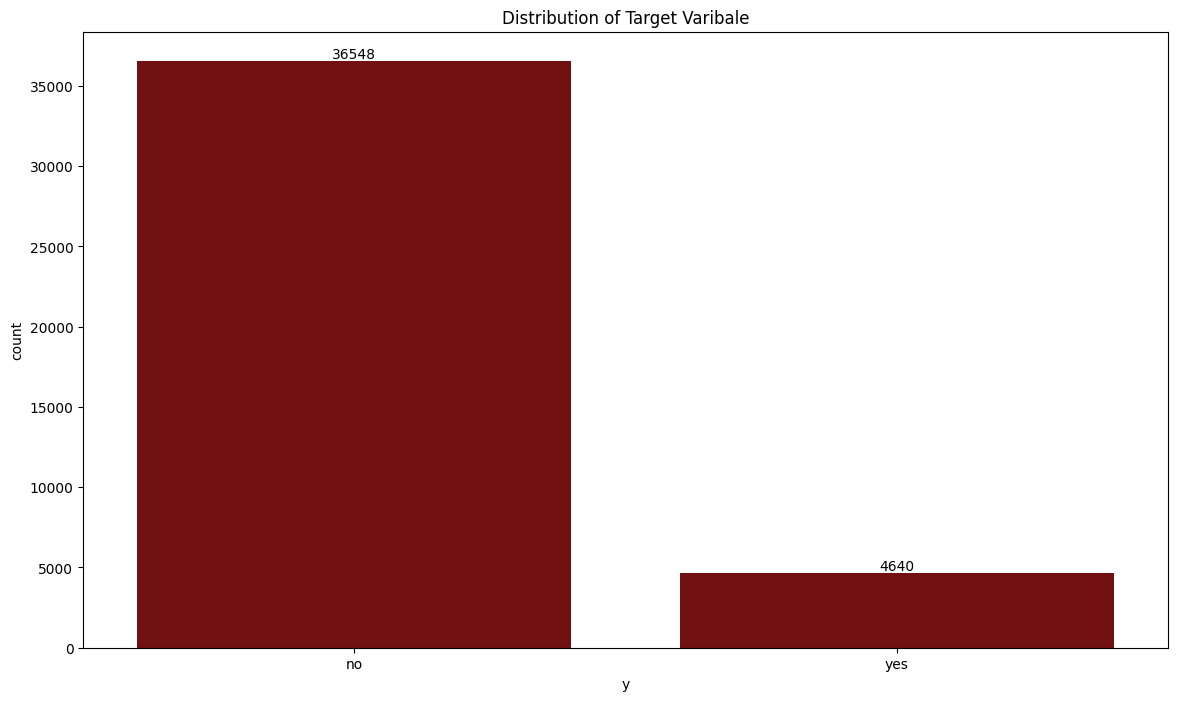

In [7]:
# Checking for the Distribution in Target Variable

Target = df['y']

plt.figure(figsize=(14,8))
ax = sns.barplot(x = Target.value_counts().index , y = Target.value_counts() , color='Maroon')
ax.bar_label(ax.containers[0])
ax.set_title("Distribution of Target Varibale");

# The target variable class imbalanced so we can accuracy might not be a good indicator to use as it is.

#### 3.3 Distribution of Numerical Features

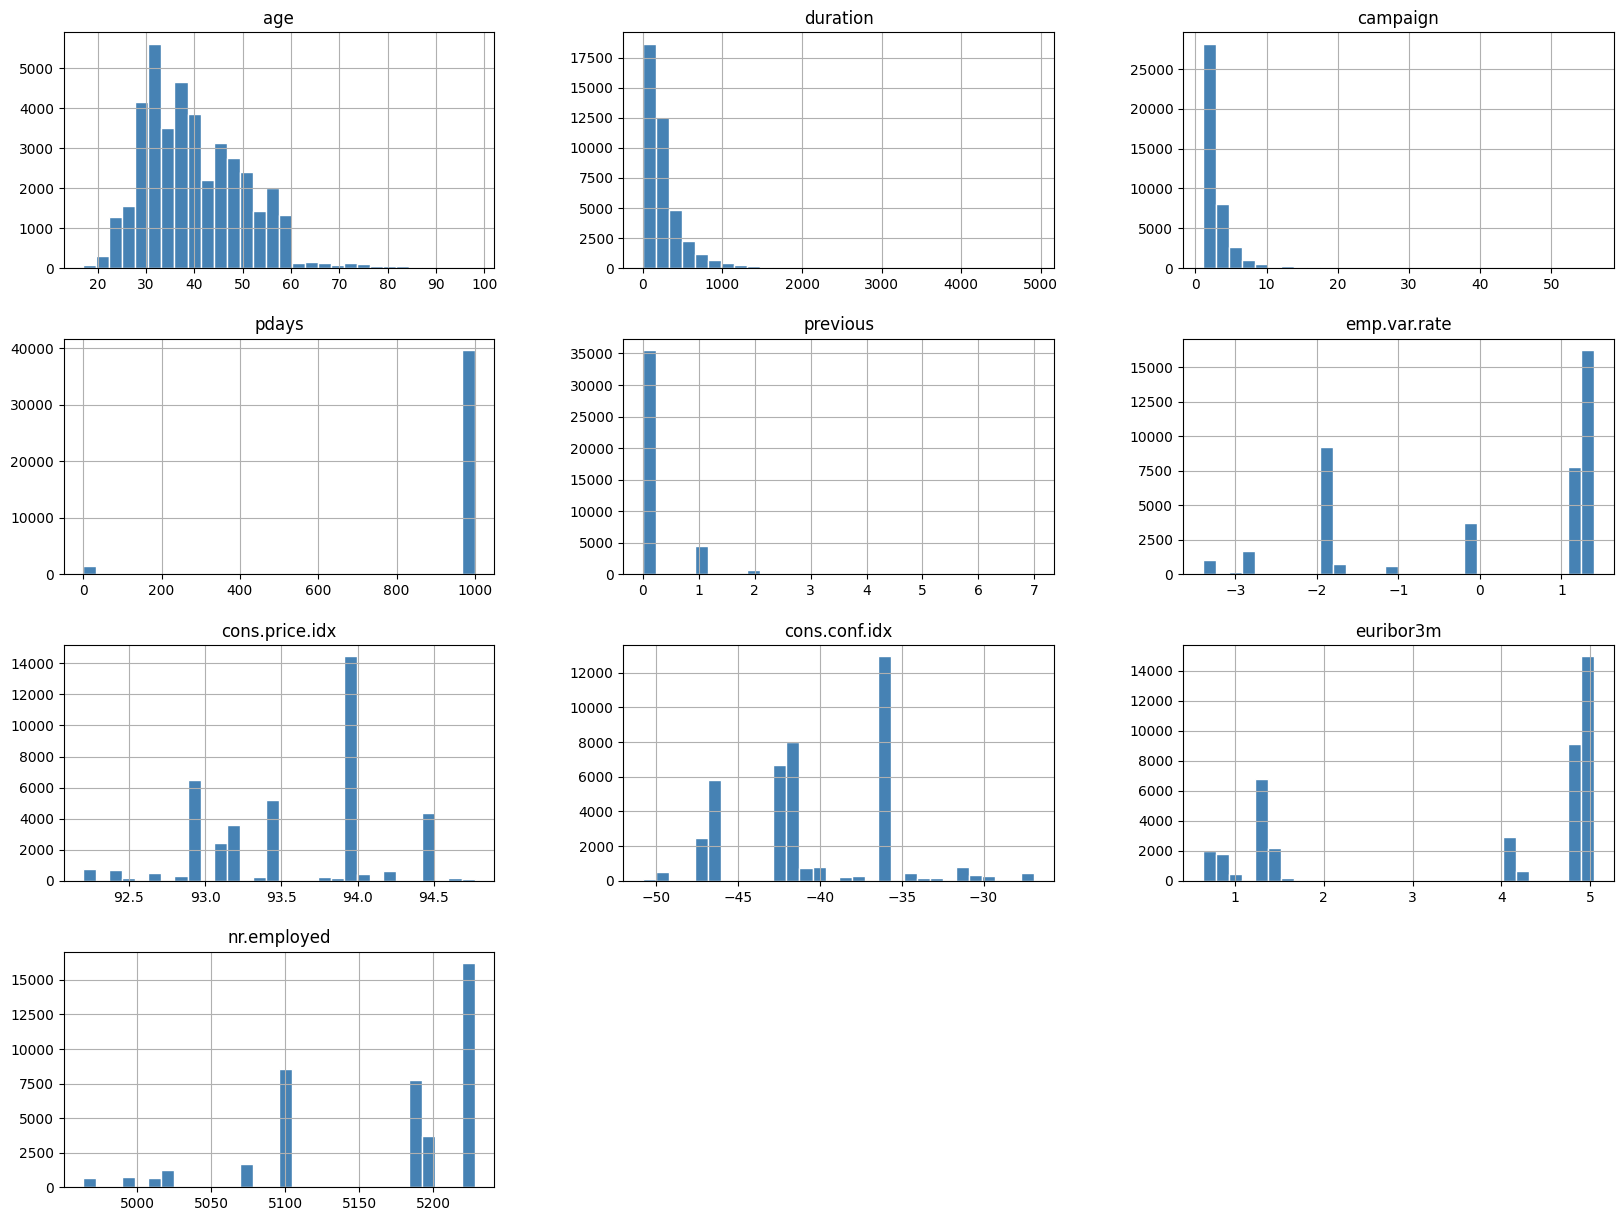

In [8]:
Numerical_Features = df.select_dtypes(include=('int' , 'float'))
Numerical_Features.hist(figsize=(20, 15), bins=30, color='steelblue', edgecolor='white')
plt.tight_layout;

# There are few right skewed features, need to do log transformation during feature engineering

#### 3.4 Correlation Between Features

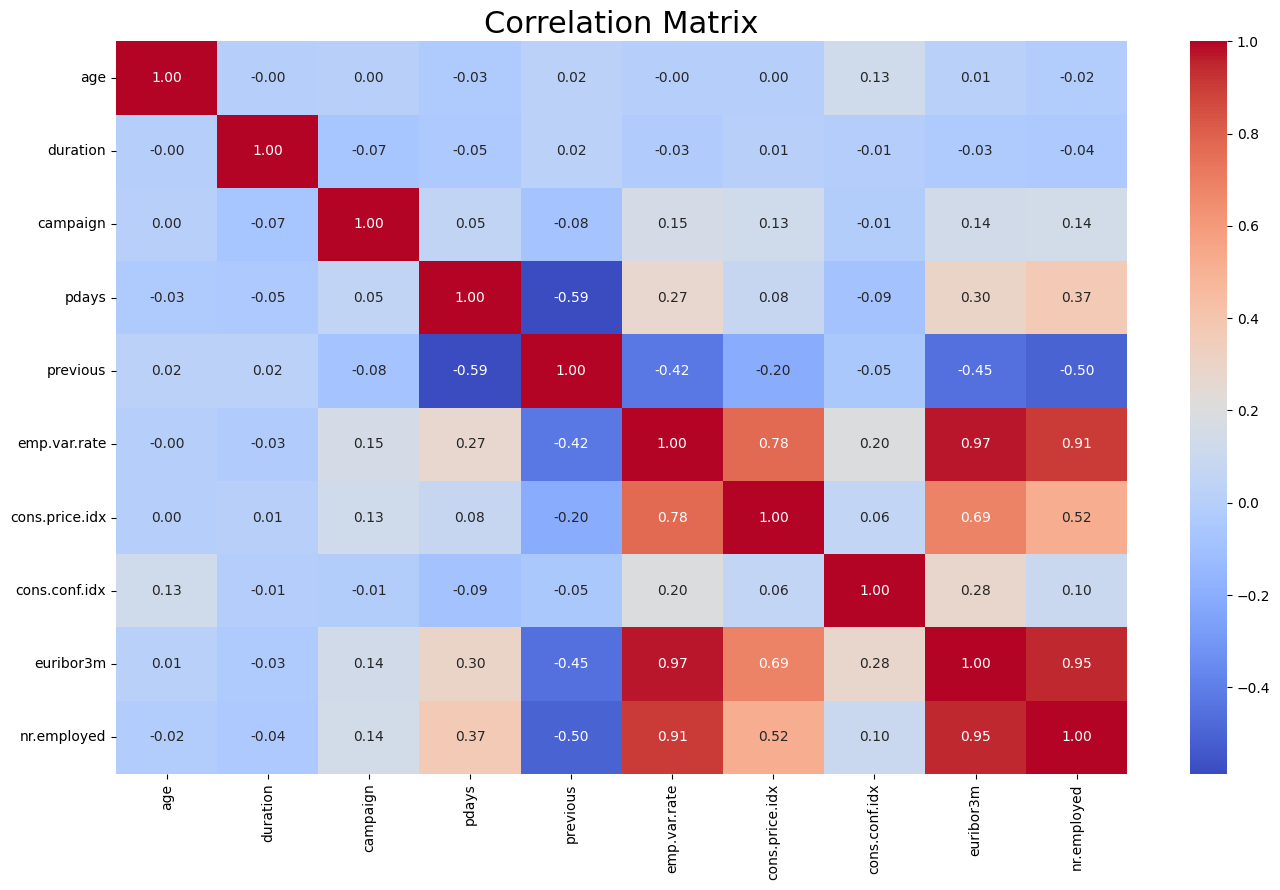

In [9]:
plt.figure(figsize=(14,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix',fontsize = 22)
plt.tight_layout();


#### 3.5 Checking for Outliers

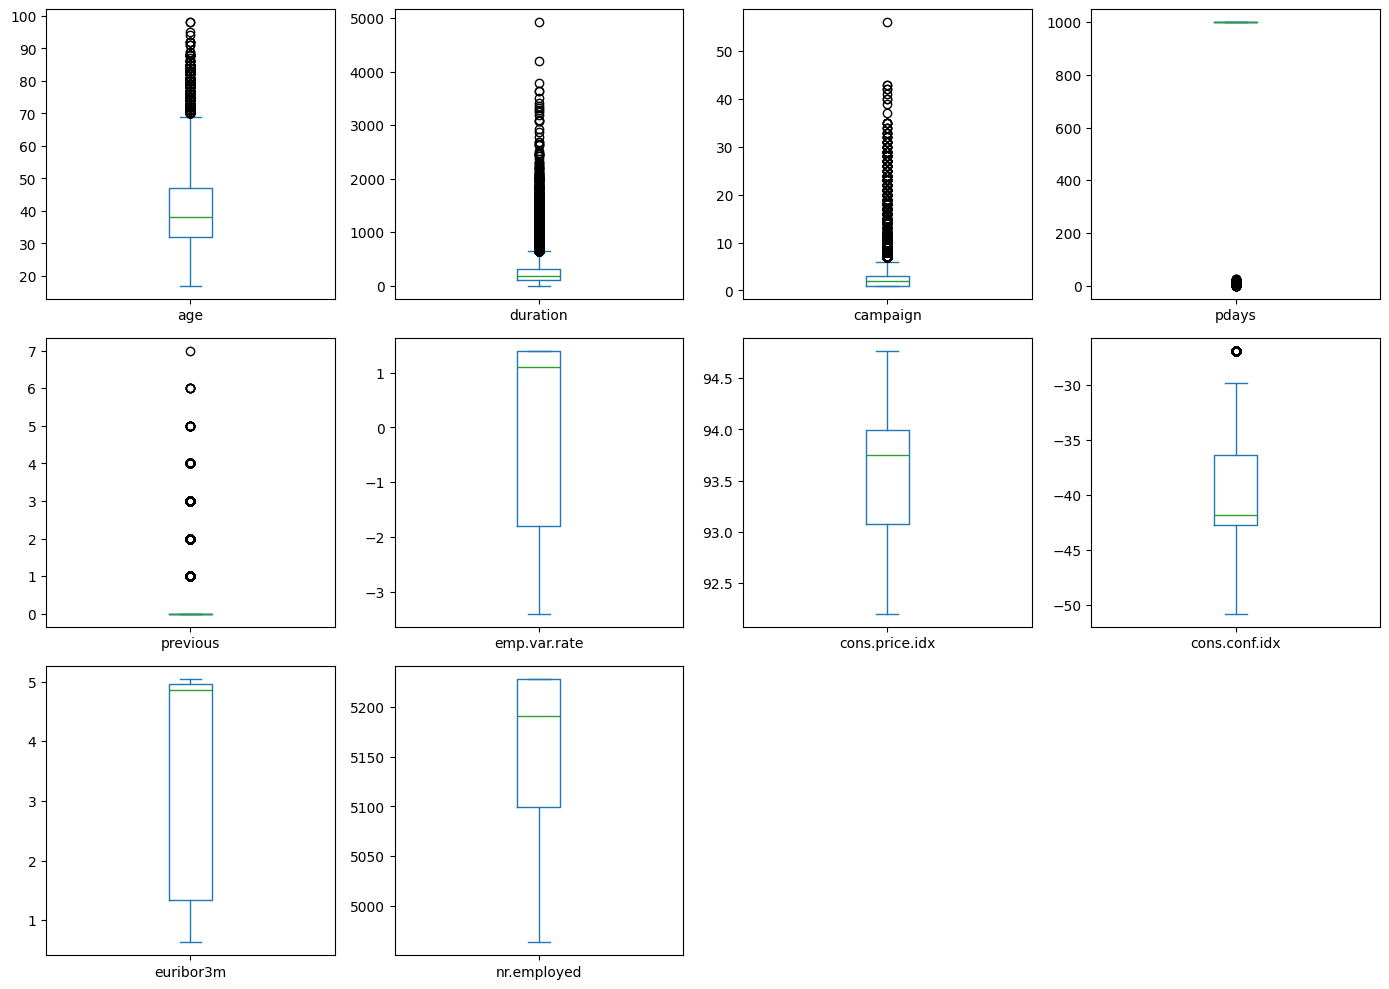

In [10]:
Numerical_Features.plot(kind = 'box' ,subplots= True , layout=(3, 4), figsize=(14, 10) )
plt.tight_layout()

## 4. Cleaning The Data

In [11]:
# Dropping Duplicates

df = df.drop_duplicates()

df.shape

(41176, 21)

In [12]:
# Changing Col Names

df = df.rename( columns={
    'emp.var.rate': 'employment variation rate'
    ,'cons.price.idx': 'consumer price index'     
    ,'cons.conf.idx': 'consumer confidence index'    
    ,'euribor3m': 'euribor 3 month rate'
    ,'nr.employed': 'number of employees'
})


In [13]:
# Log Transforming The Skewed Features

Numerical_Features = df.select_dtypes(include=("int" , "float"))
Skew = Numerical_Features.apply(lambda x : x.skew())

right_skewed = Skew[Skew > 1].index.tolist()
left_skewed = Skew[Skew < -1].index.tolist()

print(right_skewed)
print(left_skewed)

print(f'{df['duration'].skew():.2f}')

['duration', 'campaign', 'previous']
['pdays', 'number of employees']
3.26


In [14]:
#log transforming left and right skewed features

for i in right_skewed:
    if df[i].min() >=0:
        df[i] = np.log1p(df[i])


for i in left_skewed:
    if i not in right_skewed:
        df[i] = np.log1p(df[i].max() - df[i])

print(f'{df['duration'].skew():.2f}')

-0.42


## 5. Train Test Split

In [15]:
# Splitting the data into Train/Temp Split

X = df.drop(columns = 'y')
y = df['y']
X_Train , X_Temp , y_train , y_temp = train_test_split( X , y , test_size = 0.3 , random_state = 42 , stratify = y)


In [16]:
# Splitting the data into Val/Test Sets 

X_Val , X_Test , y_val , y_test = train_test_split( X_Temp , y_temp
                                                   , test_size = 0.5 , random_state = 42 , stratify = y_temp)


In [17]:
print(f'Train Shape : {X_Train.shape} ,| Val Shape : {X_Val.shape}, | Test Shape : {X_Test.shape} ')

Train Shape : (28823, 20) ,| Val Shape : (6176, 20), | Test Shape : (6177, 20) 


## 6. Feature Engineering

In [18]:
# Encoding Categorical Features

edu_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
             'high.school', 'professional.course', 'university.degree']

# Ordinal Feature Encoding

Ord_enc = OrdinalEncoder(categories= [edu_order] , handle_unknown= 'use_encoded_value' , unknown_value= -1)
X_Train['education'] = Ord_enc.fit_transform(X_Train[['education']])
X_Val['education'] = Ord_enc.transform(X_Val[['education']])
X_Test['education'] = Ord_enc.transform(X_Test[['education']])


# One-Hot Feature Encoding

nominal_cols = ['job', 'marital', 'contact', 'poutcome', 'housing', 'loan', 'default' , 'month' , 'day_of_week']
X_Train = pd.get_dummies(X_Train ,columns= nominal_cols , drop_first=True)
X_Val = X_Val.reindex(columns=X_Train.columns , fill_value = 0)
X_Test = X_Test.reindex(columns=X_Train.columns , fill_value=0)

y_train = y_train.map({'yes': 1 , 'no': 0})
y_val = y_val.map({'yes':1 , 'no' : 0})
y_test = y_test.map({'yes':1 , 'no':0})

## 7. Feature Scaling

In [19]:

# Scaling the Train / Val / Test Data

Scaler = StandardScaler()

X_Train_Scaled = Scaler.fit_transform(X_Train)
X_Val_Scaled = Scaler.transform(X_Val)
X_Test_Scaled = Scaler.transform(X_Test)



# Handling Class Imbalance With SMOTE

smote = SMOTE(random_state=42)
X_Train_Balanced , y_Train_Balanced = smote.fit_resample(X_Train_Scaled , y_train)

print(f'After SMOTE - Train Shape: {X_Train_Balanced.shape}')
print(f'Class Balanace after SMOTE : {pd.Series(y_Train_Balanced).value_counts().to_dict()}')

After SMOTE - Train Shape: (51152, 47)
Class Balanace after SMOTE : {0: 25576, 1: 25576}


## 8. Training and Validating Models

In [26]:


base_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'SVM'                 : SVC(probability=True, random_state=42)
}

results       = {}
trained_models = {}

for name, model in base_models.items():
    model.fit(X_Train_Balanced, y_Train_Balanced)


    y_train_pred = model.predict(X_Train_Balanced)
    y_train_pred_prob = model.predict_proba(X_Train_Balanced)[:, 1]

    y_val_pred      = model.predict(X_Val_Scaled)
    y_val_pred_prob = model.predict_proba(X_Val_Scaled)[:, 1]

    results[name] = {
        'train_auc' : roc_auc_score(y_Train_Balanced, y_train_pred_prob),
        'val_auc'   : roc_auc_score(y_val, y_val_pred_prob),
        'val_recall': recall_score(y_val, y_val_pred),
        'val_f1'    : f1_score(y_val, y_val_pred),
    }
    trained_models[name] = model

    gap = results[name]['train_auc'] - results[name]['val_auc']

    print(f"{name:<25} Train AUC: {results[name]['train_auc']:.4f} | "
          f"{name:<25} Val Recall: {results[name]['val_recall']:.4f} | "
          f"Val AUC: {results[name]['val_auc']:.4f} | "
          f"Gap: {gap:.4f}")

sorted_models = sorted(results, key=lambda x: results[x]['val_auc'], reverse=True)
top_name    = sorted_models[:1]

print(f"\nTop model for tuning: {top_name}")
top_model = {name: trained_models[name] for name in top_name}

Logistic Regression       Train AUC: 0.9442 | Logistic Regression       Val Recall: 0.8678 | Val AUC: 0.9121 | Gap: 0.0321
Decision Tree             Train AUC: 1.0000 | Decision Tree             Val Recall: 0.6566 | Val AUC: 0.7794 | Gap: 0.2206
Random Forest             Train AUC: 1.0000 | Random Forest             Val Recall: 0.8118 | Val AUC: 0.9196 | Gap: 0.0804
Gradient Boosting         Train AUC: 0.9883 | Gradient Boosting         Val Recall: 0.8003 | Val AUC: 0.9372 | Gap: 0.0511
KNN                       Train AUC: 0.9976 | KNN                       Val Recall: 0.4842 | Val AUC: 0.7956 | Gap: 0.2021
SVM                       Train AUC: 0.9743 | SVM                       Val Recall: 0.7960 | Val AUC: 0.9155 | Gap: 0.0588

Top model for tuning: ['Gradient Boosting']


## 9. HyperParameter Tuning

In [25]:
parameter_direc = {
    'n_estimators' : randint(100 , 300)
    ,'learning_rate' : uniform(0.01 , 0.2)
    ,'max_depth' : randint(3 ,10)
    ,'subsample' : uniform(0.6 , 0.4) 
}

cv = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 42)

search = RandomizedSearchCV(
    estimator = GradientBoostingClassifier(random_state = 42)
    ,param_distributions = parameter_direc
    ,n_iter = 20
    ,scoring = 'recall'
    ,cv = cv
    ,random_state = 42
    ,n_jobs = -1
    ,verbose = 2 ) 

search.fit(X_Train_Balanced , y_Train_Balanced)

best_gb = search.best_estimator_
y_pred = best_gb.predict(X_Val_Scaled)
y_pred_prob = best_gb.predict_proba(X_Val_Scaled)[:, 1]


print(f"Best params : {search.best_params_}")
print(f"Val Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"Val Recall  : {recall_score(y_val, y_pred):.4f}")
print(f"Val F1      : {f1_score(y_val, y_pred):.4f}")
print(f"Val AUC     : {roc_auc_score(y_val, y_pred_prob):.4f}")




Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END learning_rate=0.0849080237694725, max_depth=7, n_estimators=114, subsample=0.892797576724562; total time=  23.5s
[CV] END learning_rate=0.0849080237694725, max_depth=7, n_estimators=114, subsample=0.892797576724562; total time=  23.6s
[CV] END learning_rate=0.0849080237694725, max_depth=7, n_estimators=114, subsample=0.892797576724562; total time=  23.6s
[CV] END learning_rate=0.0849080237694725, max_depth=7, n_estimators=114, subsample=0.892797576724562; total time=  23.7s
[CV] END learning_rate=0.0849080237694725, max_depth=7, n_estimators=114, subsample=0.892797576724562; total time=  23.9s
[CV] END learning_rate=0.12973169683940733, max_depth=9, n_estimators=221, subsample=0.662397808134481; total time=  43.5s
[CV] END learning_rate=0.12973169683940733, max_depth=9, n_estimators=221, subsample=0.662397808134481; total time=  43.9s
[CV] END learning_rate=0.12973169683940733, max_depth=9, n_estimators=221, subsamp

## 10. Running The Best Model On Test Data

In [28]:
y_test_pred = best_gb.predict(X_Test_Scaled)
y_test_pred_prob = best_gb.predict_proba(X_Test_Scaled)[:,1]

print(f"Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test Recall   : {recall_score(y_test, y_test_pred):.4f}")
print(f"Test F1       : {f1_score(y_test, y_test_pred):.4f}")
print(f"Test AUC      : {roc_auc_score(y_test, y_test_pred_prob):.4f}")


Test Accuracy : 0.8876
Test Recall   : 0.8190
Test F1       : 0.6216
Test AUC      : 0.9413


In [29]:
print("=" * 45)
print("        FINAL MODEL SUMMARY")
print("=" * 45)
print(f"Model        : Gradient Boosting (Tuned)")
print(f"Test Accuracy: 0.8876")
print(f"Test Recall  : 0.8190")
print(f"Test F1      : 0.6216")
print(f"Test AUC     : 0.9413")
print("=" * 45)

        FINAL MODEL SUMMARY
Model        : Gradient Boosting (Tuned)
Test Accuracy: 0.8876
Test Recall  : 0.8190
Test F1      : 0.6216
Test AUC     : 0.9413


## 11. Saving The Model Using Joblib

In [30]:
# Save the tuned model
joblib.dump(best_gb, 'gradient_boosting_model.pkl')

# Save the scaler 
joblib.dump(Scaler, 'scaler.pkl')

# Save the ordinal encoder — needed for education column
joblib.dump(Ord_enc, 'ordinal_encoder.pkl')

print("Model, Scaler and Encoder saved successfully.")

Model, Scaler and Encoder saved successfully.
